In [6]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
class ChatState(MessagesState):
    summary: str

In [ ]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    # SEND conversation to model for summarization
    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [7]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [8]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [9]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [10]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

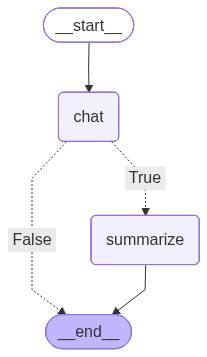

In [11]:
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [13]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d2da7d39-96a5-4932-9a77-fdb59a2bc10e')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics is a branch of physics that focuses on the behavior of particles


In [15]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d2da7d39-96a5-4932-9a77-fdb59a2bc10e'), AIMessage(content='Quantum physics is a branch of physics that focuses on the behavior of particles at the smallest scales of energy levels of atoms and subatomic particles. It deals with the fundamental principles of quantum mechanics, including the wave-particle duality of particles, superposition, entanglement, and quantization. Quantum physics has led to many technological advancements, such as quantum computing and quantum cryptography, and has also provided deeper insights into the nature of reality and the universe. It is a highly complex and interdisciplinary field that continues to push the boundaries of our understanding of the physical world.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 10, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'aud

In [19]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Explain special theory of relativity', additional_kwargs={}, response_metadata={}, id='42a5e491-8cba-4fed-ac96-cdf615dffcec'), AIMessage(content="The special theory of relativity, developed by Albert Einstein in 1905, revolutionized our understanding of space and time. The theory is based on two fundamental principles:\n\n1. The Principle of Relativity: The laws of physics are the same for all observers in uniform motion. In other words, there is no absolute frame of reference, and the laws of physics hold true regardless of the observer's velocity.\n\n2. The Constancy of the Speed of Light: The speed of light in a vacuum is the same for all observers, regardless of their motion relative to the source of light. This means that the speed of light is a universal constant.\n\nFrom these two principles, Einstein derived several important consequences, including:\n\n1. Time Dilation: According to special relativity, time is relative and can be dilated or contracted de

In [20]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Explain special theory of relativity', additional_kwargs={}, response_metadata={}, id='42a5e491-8cba-4fed-ac96-cdf615dffcec'), AIMessage(content="The special theory of relativity, developed by Albert Einstein in 1905, revolutionized our understanding of space and time. The theory is based on two fundamental principles:\n\n1. The Principle of Relativity: The laws of physics are the same for all observers in uniform motion. In other words, there is no absolute frame of reference, and the laws of physics hold true regardless of the observer's velocity.\n\n2. The Constancy of the Speed of Light: The speed of light in a vacuum is the same for all observers, regardless of their motion relative to the source of light. This means that the speed of light is a universal constant.\n\nFrom these two principles, Einstein derived several important consequences, including:\n\n1. Time Dilation: According to special relativity, time is relative and can be dilated or contracted de